In [1]:
from pylab import *
import numpy as np
import matplotlib.pyplot as plt
import scienceplots as sps
plt.style.use(['science', 'no-latex'])

def field_field_coherence(x,y,dt, trl_indx = None):

    if trl_indx is not None:
        x = x[trl_indx,:]
        y = y[trl_indx,:]
#    print(x.shape)
        
    T = x.shape[0]    
    N = x.shape[1] 
    
    #generating arrays
    SYY = np.zeros(int(N/2+1))                            
    SXX = np.zeros(int(N/2+1))                        
    SYX = np.zeros(int(N/2+1), dtype=complex)           

    #loop over trials
    for k in range(T):                                

        yf = rfft((y[k,:]) *hanning(N))   #rfft of y 
        nf = rfft((x[k,:]) *hanning(N))   #rfft of x
        SYY = SYY + ( real( yf*conj(yf) ) )/T       #this appends power spectra (for y) for this trial
        SXX = SXX + ( real( nf*conj(nf) ) )/T           # ""  for x
        SYX = SYX + ( yf*conj(nf)   )/T     # "" xy

    coh = abs(SYX) / np.sqrt(SYY) / np.sqrt(SXX)            
    f = rfftfreq(N, dt)
    
    return coh, f   

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
import gc
from scipy.stats import zscore
import copy
from scipy.ndimage import gaussian_filter1d


def smooth_with_gaussian(data, sigma=3):
    return gaussian_filter1d(data, sigma=sigma, axis=1) 

def preprocess(data):
    stds = np.std(data[:, :], axis=0)
    non_constant_cols = stds.astype(float) > 1e-6    #finds the time points where std is not 0
    const_cols = stds.astype(float) <= 1e-6    #finds the time points where std is 0

    z = np.zeros_like(data[:, :])   #creates an array of zeros with the same shape as the data
    z[:, non_constant_cols] = zscore(data[:, non_constant_cols], axis=0)  #in the columns where std is not 0, zscores the data
    z[:, const_cols] = np.mean(data[:, const_cols], axis=0)

 
    if np.isnan(z).any():
        raise ValueError("Data contains NaN values after normalization.")

    return z

def sample_plots(l_al, r_al, a_al, l_ar, r_ar, a_ar, width, height):
    #plotting some traces
    fig, ax = plt.subplots(1, 2, figsize=(width, height))
    ax[0].plot(np.mean(l_al, axis = 0), label = 'left')
    ax[0].plot(np.mean(r_al, axis = 0), label = 'right')
    ax[0].plot(np.mean(a_al, axis = 0), label = 'attention')
    ax[0].set_title('attention left - mean across trials')
    ax[1].plot(np.mean(l_ar, axis = 0), label = 'left')
    ax[1].plot(np.mean(r_ar, axis = 0), label = 'right')
    ax[1].plot(np.mean(a_ar, axis = 0), label = 'attention')
    ax[1].set_title('attention right - mean across trials')
    plt.legend()
    plt.show()

    plt.plot(np.mean(l_al, axis = 0), label = 'left input - attleft')
    plt.plot(-1 * np.mean(l_ar, axis = 0), label = 'negative of left input - attright')
    plt.title('mean of left attleft and negative of left attright')
    plt.legend()
    plt.show()

    fign, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].plot(l_al[0, :], label = 'left input - attleft')
    ax[0].plot(r_al[0, :], label = 'right input - attleft')
    ax[0].plot(a_al[0, :], label = 'attention - attleft')
    ax[0].set_title('trial 0 attleft data')
    ax[1].plot(l_ar[0, :], label = 'left input - attright')
    ax[1].plot(r_ar[0, :], label = 'right input - attright')
    ax[1].plot(a_ar[0, :], label = 'attention - attright')
    ax[1].set_title('trial 0 attright data')
    plt.legend()
    plt.show()

In [ ]:
file_numbers = [1, 2, 3, 4, 8, 14, 15, 20, 23]
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
dt = 0.002

structure = {file_number: {
    'left_attleft': [],
    'right_attleft': [],
    'left_attright': [],
    'right_attright': []
} for file_number in file_numbers} 

coherence_results = copy.deepcopy(structure)


total_time = time.time()
for file_number in  file_numbers:
    file_total = time.time()
    file_path = f'C:/Users/joshu/PartIIIProject/RSNNdale_attention_{file_number}_attention_test'
    load_data_start_time = time.time()
    data = pickle.load(open(file_path, 'rb'))
    elapsed_time = time.time() - load_data_start_time
    print(f"Dataset {file_number} loaded in {elapsed_time:.2f} seconds")

    attention_labels = data['label_attend'][0]
    label_left = data['label_left'][0]
    label_right = data['label_right'][0]
    attend_01 = data['attend'][0]
    omitted = data['omit'][0]
    trial_correct = data['trial_correct'][0]
    relevant = np.where((omitted == 0) & (trial_correct == 1))[0]

    left = data['SP'][0][0][relevant, 100:350, :]
    right = data['SP'][0][1][relevant, 100:350, :]
    att = data['SP'][0][2][relevant, 100:350, :]

    num_trials, num_samples, num_neurons = left.shape
    num_neurons_attention = 80

    for j in range(0, num_trials):
        for i in range(0, num_neurons):
            count_left = np.count_nonzero(left[j, :, i] == 1)
            if count_left > 0:
                left[j, :, i] /= count_left
            count_right = np.count_nonzero(right[j, :, i] == 1)
            if count_right > 0:
                right[j, :, i] /= count_right

        for i in range(0, num_neurons_attention):
            count_attention = np.count_nonzero(att[j, :, i] == 1)
            if count_attention > 0:
                att[j, :, i] /= count_attention

    left = np.sum(left, axis=2)  # Return a single time series for the output
    right = np.sum(right, axis=2)
    att = np.sum(att, axis=2)

    left = smooth_with_gaussian(left, sigma=2)  # Axis 1 will smooth all of these across time
    right = smooth_with_gaussian(right, sigma=2)    
    att = smooth_with_gaussian(att, sigma=2)

    left = preprocess(left)
    right = preprocess(right)
    att = preprocess(att)
   
    # Can now split into left and right attentional modality
    left_indices_agg = np.where((omitted == 0) & (attend_01 == 0) & (label_left != label_right))[0]  # Indices of agg where left
    _, left_indices, _ = np.intersect1d(relevant, left_indices_agg, return_indices = True)   # Indices for relevant processed data where attention left
    right_indices_agg = np.where((omitted == 0) & (attend_01 == 1) & (label_left != label_right))[0]
    _, right_indices, _ = np.intersect1d(relevant, right_indices_agg, return_indices = True)

    l_al = left[left_indices]
    r_al = right[left_indices]
    a_al = att[left_indices]

    l_ar = left[right_indices]
    r_ar = right[right_indices]
    a_ar = att[right_indices]

    #----- computing coherence ----------------
    left_attleft_coherence, freq_lal = field_field_coherence(
        l_al, a_al, dt)
    right_attleft_coherence, freq_ral = field_field_coherence(
        r_al, a_al, dt)
    left_attright_coherence, freq_lar = field_field_coherence(
        l_ar, a_ar, dt)
    right_attright_coherence, freq_rar = field_field_coherence(
        r_ar, a_ar, dt)

        
    coherence_results[file_number]['left_attleft'].append(left_attleft_coherence)
    coherence_results[file_number]['right_attleft'].append(right_attleft_coherence)
    coherence_results[file_number]['left_attright'].append(left_attright_coherence)
    coherence_results[file_number]['right_attright'].append(right_attright_coherence)

    del l_al, r_al, a_al, l_ar, r_ar, a_ar
    gc.collect()
    del(data)
    gc.collect()
    file_time = time.time() - file_total
    print(f'Dataset {file_number} complete in {file_time:.2f} seconds')

time_elapsed = time.time() - total_time
print(f'total time elapsed = {time_elapsed:.2f} seconds')


Dataset 1 loaded in 8.01 seconds
(328, 250)
(350, 250)
Dataset 1 complete in 11.18 seconds
Dataset 2 loaded in 6.74 seconds
(333, 250)
(359, 250)
Dataset 2 complete in 10.93 seconds
Dataset 3 loaded in 5.92 seconds
(329, 250)
(343, 250)
Dataset 3 complete in 9.07 seconds
Dataset 4 loaded in 6.07 seconds
(305, 250)
(237, 250)
Dataset 4 complete in 8.26 seconds
Dataset 8 loaded in 6.05 seconds
(339, 250)
(336, 250)
Dataset 8 complete in 8.28 seconds
Dataset 14 loaded in 5.22 seconds
(335, 250)
(352, 250)
Dataset 14 complete in 7.97 seconds
Dataset 15 loaded in 5.72 seconds
(318, 250)
(366, 250)
Dataset 15 complete in 8.52 seconds
Dataset 20 loaded in 8.65 seconds
(325, 250)
(350, 250)
Dataset 20 complete in 11.09 seconds
Dataset 23 loaded in 5.10 seconds
(328, 250)
(339, 250)
Dataset 23 complete in 7.31 seconds
total time elapsed = 82.62 seconds


In [15]:
%config InlineBackend.figure_format = 'retina'

In [16]:
print(freq_lal)

[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178. 180. 182. 184. 186. 188. 190. 192. 194.
 196. 198. 200. 202. 204. 206. 208. 210. 212. 214. 216. 218. 220. 222.
 224. 226. 228. 230. 232. 234. 236. 238. 240. 242. 244. 246. 248. 250.]


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

# === 1. Extract coherence arrays per subject ===
l_al = np.array([coherence_results[file_number]['left_attleft'][0] for file_number in coherence_results])
r_ar = np.array([coherence_results[file_number]['right_attright'][0] for file_number in coherence_results])
r_al = np.array([coherence_results[file_number]['right_attleft'][0] for file_number in coherence_results])
l_ar = np.array([coherence_results[file_number]['left_attright'][0] for file_number in coherence_results])

# === 2. Combine into 'in' and 'out' conditions ===
# Each is now shape: (n_subjects, n_freqs)
in_data = 0.5 * (l_al + r_ar)
out_data = 0.5 * (r_al + l_ar)

# === 3. Restrict to frequencies ≤ 80 Hz ===
freq_mask = freq_lal <= 80
frequencies = freq_lal[freq_mask]
in_data = in_data[:, freq_mask]
out_data = out_data[:, freq_mask]


# === 9. Band-averaged coherence tests ===
bands = {
    "delta": (0, 3.9),
    "theta": (4, 7.9),
    "alpha": (8, 12.9),
    "beta": (13, 29.9),
    "gamma": (30, 80)
}

band_means_in = []
band_means_out = []

print("\nBand-Averaged Coherence Tests:")
for band_name, (fmin, fmax) in bands.items():
    band_mask = (frequencies >= fmin) & (frequencies <= fmax)
    
    # Skip if band has no data points
    if not np.any(band_mask):
        print(f"{band_name.capitalize()} band: No data in range ({fmin}-{fmax} Hz)")
        continue

    # Compute mean per subject within band
    in_band = in_data[:, band_mask].mean(axis=1)
    out_band = out_data[:, band_mask].mean(axis=1)

    # Fisher transform before testing
    z_in = np.arctanh(np.sqrt(in_band))
    z_out = np.arctanh(np.sqrt(out_band))

    band_means_in.append(z_in)
    band_means_out.append(z_out)

band_means_in = np.array(band_means_in)   # shape (n_bands, n_subjects)
band_means_out = np.array(band_means_out) # shape (n_bands, n_subjects)

from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

t_stats_band, p_values_band = ttest_rel(band_means_in, band_means_out, axis=1)
print(p_values_band)
rej_band, pvals_corrected_band, _, _ = multipletests(p_values_band, method='fdr_bh')

for i, band_name in enumerate(bands.keys()):
    print(f"{band_name.capitalize()} band: t-statistic = {t_stats_band[i]:.3f}, "
          f"p-value (FDR corrected) = {pvals_corrected_band[i]:.4f}, "
          f"Significant: {rej_band[i]}")



Band-Averaged Coherence Tests:
[0.01596796 0.10047438 0.10901782 0.00997371 0.06307682]
Delta band: t-statistic = 3.044, p-value (FDR corrected) = 0.0399, Significant: True
Theta band: t-statistic = 1.856, p-value (FDR corrected) = 0.1090, Significant: False
Alpha band: t-statistic = 1.803, p-value (FDR corrected) = 0.1090, Significant: False
Beta band: t-statistic = 3.357, p-value (FDR corrected) = 0.0399, Significant: True
Gamma band: t-statistic = 2.157, p-value (FDR corrected) = 0.1051, Significant: False


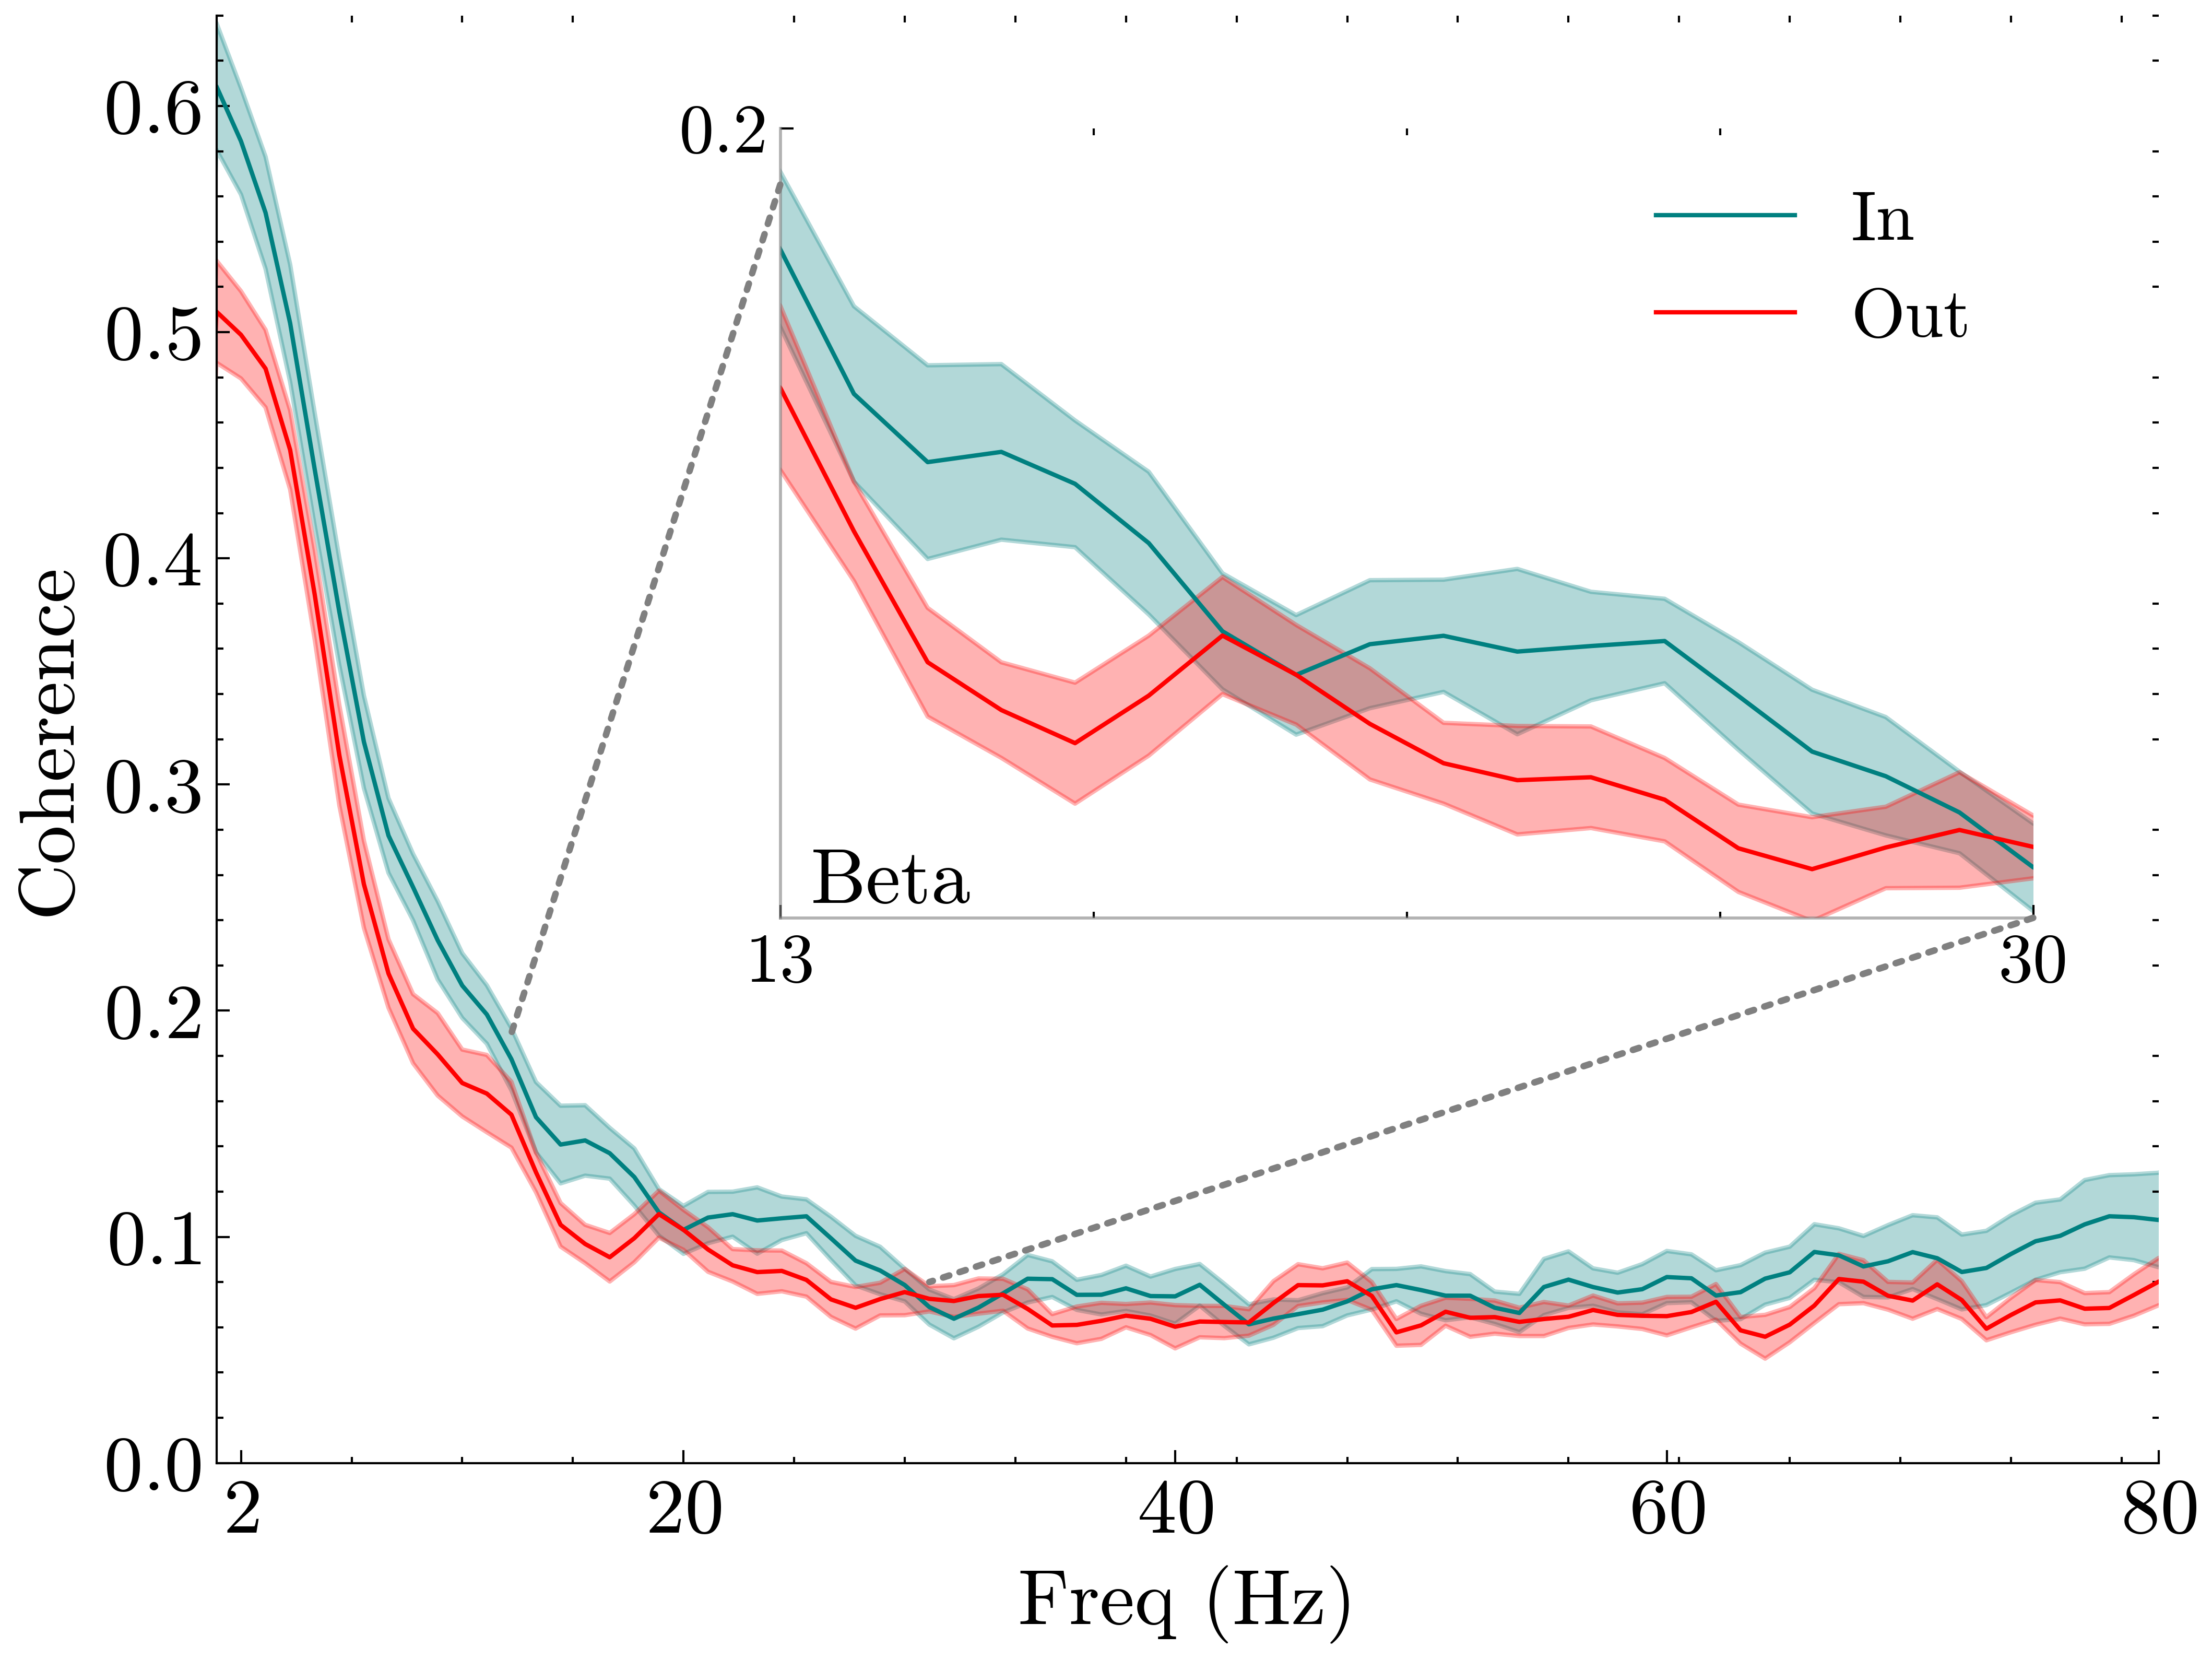

In [70]:
def plot_coh_broadband(data):
    l_al = np.sum([coherence_results[file_number]['left_attleft'][0] for file_number in coherence_results], axis=0)
    r_al = np.sum([coherence_results[file_number]['right_attleft'][0] for file_number in coherence_results], axis=0)
    l_ar = np.sum([coherence_results[file_number]['left_attright'][0] for file_number in coherence_results], axis=0)
    r_ar = np.sum([coherence_results[file_number]['right_attright'][0] for file_number in coherence_results], axis=0)

    l_al = l_al / len(coherence_results)
    r_al = r_al / len(coherence_results)
    l_ar = l_ar / len(coherence_results)
    r_ar = r_ar / len(coherence_results)

    #errors
    l_al_err = np.std([coherence_results[file_number]['left_attleft'][0] for file_number in coherence_results], axis=0) / np.sqrt(len(coherence_results))
    r_al_err = np.std([coherence_results[file_number]['right_attleft'][0] for file_number in coherence_results], axis=0) / np.sqrt(len(coherence_results))
    l_ar_err = np.std([coherence_results[file_number]['left_attright'][0] for file_number in coherence_results], axis=0) / np.sqrt(len(coherence_results))
    r_ar_err = np.std([coherence_results[file_number]['right_attright'][0] for file_number in coherence_results], axis=0) / np.sqrt(len(coherence_results))

    f = np.arange(0, len(l_al), 1)

    smooth_with_gaussian = lambda x, window: np.convolve(x, np.ones(window)/window, mode='same')

    in_data = (l_al + r_ar) / 2
    in_data = smooth_with_gaussian(in_data, 2)
    out_data = (r_al + l_ar) / 2
    out_data = smooth_with_gaussian(out_data, 2)
    in_errors = np.sqrt((l_al_err ** 2 + r_ar_err ** 2) / 4)
    out_errors = np.sqrt((r_al_err ** 2 + l_ar_err ** 2) / 4)

    # Add inset plot to the first (broadband) plot
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
    ax.plot(f, in_data, label='In', color='teal')
    ax.fill_between(f, in_data - in_errors, in_data + in_errors, color='teal', alpha=0.3)
    ax.plot(f, out_data, label='Out', color='red')
    ax.fill_between(f, out_data - out_errors, out_data + out_errors, color='red', alpha=0.3)
    ax.set_xlabel('freq (Hz)')
    ax.set_xlim(1, 80)
    ax.set_xticks([2, 20, 40, 60, 80])
    ax.set_ylabel('Coherence')
    ax.set_ylim(0., 0.64)
    ax.set_xlabel('Freq (Hz)', fontsize=18)
    ax.set_ylabel('Coherence', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)
    # Remove top and right spines and their ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)

    # Add inset plot using fig.add_axes
    inset_width = 0.5
    inset_height = 0.42
    left = 0.6 - inset_width / 2
    bottom = 0.61 - inset_height / 2
    axins = fig.add_axes([left, bottom, inset_width, inset_height], zorder=5)
    axins.plot(f, in_data, label='In', color='teal')
    in_lower = np.maximum(in_data - in_errors, 1e-6)
    in_upper = np.maximum(in_data + in_errors, 1e-6)
    out_lower = np.maximum(out_data - out_errors, 1e-6)
    out_upper = np.maximum(out_data + out_errors, 1e-6)
    axins.fill_between(f, (in_lower), (in_upper), color='teal', alpha=0.3)
    axins.plot(f, out_data, label='Out', color='red')
    axins.fill_between(f, (out_lower), (out_upper), color='red', alpha=0.3)
    axins.set_xlim(13, 30)
    axins.set_ylim(0.06, 0.2)
    axins.set_yticks([0.2])
    axins.set_xticks([13, 30])
    axins.set_xticklabels(['13', '30'])
    axins.tick_params(axis='both', labelsize=16)
    axins.spines['top'].set_visible(False)
    axins.spines['right'].set_visible(False)
    axins.tick_params(top=False, right=False)
    axins.legend(fontsize=16, loc='upper right')
    band_centers = [14.5]  
    for x, label in zip(band_centers, ['Beta']):
        axins.text(x, 0.06, f'{label}', ha='center', va='bottom', fontsize=18, rotation=0)
    for spine in axins.spines.values():
        spine.set_edgecolor('gray')
        spine.set_linewidth(0.7)
        spine.set_alpha(0.6)

    # Add dotted diagonal lines to indicate zoom from main plot to inset
    y_main = ax.get_ylim()
    y_inset = axins.get_ylim()
    from matplotlib.patches import ConnectionPatch
    con1 = ConnectionPatch(xyA=(13, 0.19), coordsA=axins.transData,
                          xyB=(13, 0.19), coordsB=ax.transData,
                          color='gray', linestyle='dotted', linewidth=1.5, zorder=2000)
    fig.patches.append(con1)
    con2 = ConnectionPatch(xyA=(30, y_inset[0]), coordsA=axins.transData,
                          xyB=(30, 0.08), coordsB=ax.transData,
                          color='gray', linestyle='dotted', linewidth=1.5, zorder=2000)
    fig.patches.append(con2)

    # Move legend to the very top after all other elements
    plt.show()
    

plot_coh_broadband(coherence_results)